In [81]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn 
import seaborn as sns

In [82]:
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
cars.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


<Axes: xlabel='wt', ylabel='mpg'>

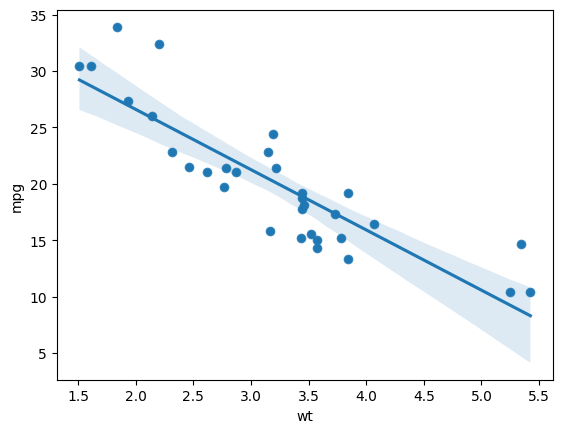

In [83]:
sns.scatterplot(x='wt', y='mpg', data=cars)
sns.regplot(x='wt', y='mpg', data=cars)

# we can see here that the mileage decreases as the weight increases
# we will replicate the regression line using neural networks

In [84]:
# convert data to tensor
X_list = cars.wt.values # get the wt column
X_np = np.array(X_list, dtype=np.float32).reshape(-1,1) # convert to numpy array

y_list = cars.mpg.values.tolist() # get the mpg column

# this is how to convert numpy arrays to tensors
X = torch.from_numpy(X_np)
# this is how to convert lists to tensors
y = torch.tensor(y_list)

In [85]:
print("X tensor")
print(X)

X tensor
tensor([[2.6200],
        [2.8750],
        [2.3200],
        [3.2150],
        [3.4400],
        [3.4600],
        [3.5700],
        [3.1900],
        [3.1500],
        [3.4400],
        [3.4400],
        [4.0700],
        [3.7300],
        [3.7800],
        [5.2500],
        [5.4240],
        [5.3450],
        [2.2000],
        [1.6150],
        [1.8350],
        [2.4650],
        [3.5200],
        [3.4350],
        [3.8400],
        [3.8450],
        [1.9350],
        [2.1400],
        [1.5130],
        [3.1700],
        [2.7700],
        [3.5700],
        [2.7800]])


In [86]:
print("y tensor")
print(y)

y tensor
tensor([21.0000, 21.0000, 22.8000, 21.4000, 18.7000, 18.1000, 14.3000, 24.4000,
        22.8000, 19.2000, 17.8000, 16.4000, 17.3000, 15.2000, 10.4000, 10.4000,
        14.7000, 32.4000, 30.4000, 33.9000, 21.5000, 15.5000, 15.2000, 13.3000,
        19.2000, 27.3000, 26.0000, 30.4000, 15.8000, 19.7000, 15.0000, 21.4000])


In [87]:
# create the weights and biases
w = torch.rand(1, requires_grad=True, dtype=torch.float64)
b = torch.rand(1, requires_grad=True, dtype=torch.float64)
print(w)
print(b)

tensor([0.5127], dtype=torch.float64, requires_grad=True)
tensor([0.7299], dtype=torch.float64, requires_grad=True)


# Learning Rate in Neural Networks

The learning rate is a crucial hyperparameter in the training of neural
networks. It determines the step size at each iteration while moving toward a
minimum of the loss function.

# Gradient Descent

<img src="figures/gradient_descent_gif.gif" alt="Alt text" width="500"
height="300">

- <b>Gradient Descent</b>: During training, the model uses an optimization
  algorithm like gradient descent to minimize the loss function. This involves
  updating the model's parameters (weights and biases) in the direction and rate that
  reduces the error. 

- <b>Step Size</b>: The learning rate controls how big these steps are. A higher learning rate means bigger steps, while a lower learning rate means smaller steps.

<img src="figures/step_size.gif" alt="Alt text" width="500"
height="300">


- <b>Balance</b>:

    `Too High`: If the learning rate is too high, the model might take large steps and overshoot the minimum. This can lead to instability and poor convergence.

    `Too Low`: If the learning rate is too low, the model will take very small steps, which can result in a very slow training process. It might also get stuck in a local minimum and never reach the best possible solution.

- <b>Adjustment</b>: Learning rate is adjusted during training. Techniques like
  learning rate schedules or adaptive learning rates (used in optimizers like
  Adam or RMSprop) help improve performance by changing the learning rate
  dynamically.


A step size of 0.5 with gradient descent will reach the minimum in one step.

Any learning rate lower than 0.5 leads to slower convergence.

Any learning rate higher than 0.5 (but less than 1) leads to oscillations around the minimum till it finally lands at the minimum.

A learning rate α=1 for this function. The iterations just keep oscillating.

A learning rate greater than 1 leads to the iterations moving away from the minimum.

In [88]:
# define the learning rate  
learning_rate = 0.01

# define the number of epochs
# epochs is the number of times the model will see the data
# An epoch of 1000 means that the neural network will go
# through the entire training dataset 1000 times during the training process.
num_epochs = 1000


In [89]:
# Loop through each epoch
# This outer loop controls how many times the model through the entire dataset.
for epoch in range(num_epochs):
    
    # Loop through each data point
    # This inner loop processes each sample in the dataset one at a time.
    for i in range(len(X)):
        
        # Make a prediction
        # Calculate the predicted value using current weights (w) and bias (b).
        y_predict = X[i] * w + b
        
        # Calculate the loss
        # Measure how far the prediction is from the actual value.
        loss_tensor = torch.pow(y_predict - y[i], 2)
        
        # Compute gradients
        # Calculate how much each parameter needs to change to reduce the loss.
        loss_tensor.backward()
        
        # Get the loss value
        # Extract the actual loss value for monitoring.
        loss_value = loss_tensor.data[0]
        
        # Update weights and biases
        # Temporarily turn off gradient tracking to update parameters.
        # Why: By default, PyTorch tracks all operations on tensors that require
        # gradients. If we don't turn off this tracking, the updates we make to
        # the weights and biases will also be tracked, which can lead to
        # incorrect gradient calculations and increased memory usage.
        
        with torch.no_grad():
            # Adjust weights and bias
            # Modify weights and bias to reduce the loss.
            w -= w.grad * learning_rate
            b -= b.grad * learning_rate
            
            # Reset gradients
            # Clear the gradients to prepare for the next iteration.
            w.grad.zero_()
            b.grad.zero_()
    
    # Print the loss value
    print(loss_value)

tensor(18.1201, dtype=torch.float64)
tensor(16.8663, dtype=torch.float64)
tensor(15.7142, dtype=torch.float64)
tensor(14.6461, dtype=torch.float64)


tensor(13.6558, dtype=torch.float64)
tensor(12.7374, dtype=torch.float64)
tensor(11.8856, dtype=torch.float64)
tensor(11.0953, dtype=torch.float64)
tensor(10.3620, dtype=torch.float64)
tensor(9.6813, dtype=torch.float64)
tensor(9.0494, dtype=torch.float64)
tensor(8.4627, dtype=torch.float64)
tensor(7.9178, dtype=torch.float64)
tensor(7.4115, dtype=torch.float64)
tensor(6.9411, dtype=torch.float64)
tensor(6.5039, dtype=torch.float64)
tensor(6.0974, dtype=torch.float64)
tensor(5.7193, dtype=torch.float64)
tensor(5.3677, dtype=torch.float64)
tensor(5.0405, dtype=torch.float64)
tensor(4.7360, dtype=torch.float64)
tensor(4.4525, dtype=torch.float64)
tensor(4.1885, dtype=torch.float64)
tensor(3.9425, dtype=torch.float64)
tensor(3.7134, dtype=torch.float64)
tensor(3.4997, dtype=torch.float64)
tensor(3.3005, dtype=torch.float64)
tensor(3.1147, dtype=torch.float64)
tensor(2.9414, dtype=torch.float64)
tensor(2.7796, dtype=torch.float64)
tensor(2.6285, dtype=torch.float64)
tensor(2.4874, dtype=to

`Insight`: It shows how the error (loss) changes over time, indicating whether the
model is learning effectively.

`Expectation`: As training progresses, we typically expect the loss value to decrease, indicating that the model's predictions are becoming more accurate.

Weight: -5.605667785304856, Bias: 36.56326931324139
[21.87641972 20.44697443 23.55812005 18.54104738 17.27977213 17.16765878
 16.55103532 18.68118908 18.90541579 17.27977213 17.27977213 13.74820143
 15.65412847 15.37384508  7.13351344  6.15812725  6.600975   24.23080019
 27.51011584 26.27686893 22.74529822 16.83131871 17.30780047 15.03750502
 15.00947668 25.71630215 24.56714025 28.08189395 18.79330243 21.03556955
 16.55103532 20.97951287]


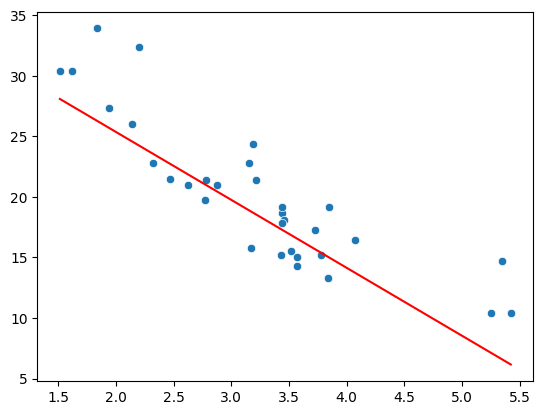

In [90]:
print(f"Weight: {w.item()}, Bias: {b.item()}")
y_pred = (torch.tensor(X_list)*w+b).detach().numpy()
sns.scatterplot(x=X_list, y=y_list)
sns.lineplot(x=X_list, y=y_pred, color='red')
print(y_pred)

In [91]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_np, y_list)
print(f"Slope: {reg.coef_}, Bias: {reg.intercept_}")

Slope: [-5.3444715], Bias: 37.285125732421875


# Congatulations you have created your first neural network